Accuracy test of seq vs par

In [1]:
import jax
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
from cmap.clqt_jax import CLQT 
from linear_model_wv_data import make_wv_data
from cmap.linear_estimation_problem import Estimation 
from cmap.convert_est_clqt import est_to_clqt
from cmap.con_to_dis import f_convert


In [ ]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass

In [ ]:
T = 1.0
q = 4.0
v = 1e-2
p0 = 0.001

t0=0.0

W = lambda t: q * jnp.eye(2)
H  = lambda t: jnp.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
R  = lambda t: v * jnp.eye(2)
P0 = p0 * jnp.eye(4)

F = lambda t: jnp.array(
        [
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
        ])

L = lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
Q = lambda t: L(t) @ W(t) @ L(t).T

c = lambda t: jnp.zeros((4,))
r = lambda t: jnp.zeros((2,))
m0 = jnp.array([5.0, 5.0, 0.0, 0.0])


In [5]:
def accuracy_test_linear_wv(steps, blocks,steps_all,T):
    steps_all=steps*blocks

    dt=T/steps_all

    X, y_discrete, _ = make_wv_data(m0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)

    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)

    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)


 
    T=clqt.T
    dt = clqt.T / steps / blocks
    ST=clqt.ST
    vT=clqt.vT

    S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT,diffeq_solver='euler')
    phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
    x_seq,u_seq =seqForwardPass(clqt, dt, t0, phi0, Kx_seq, d_seq,diffeq_solver='euler',u_zoh=False)


    Kx_par, d_par, S_par, v_par = parBackwardPass(clqt,blocks,steps,t0,dt,diffeq_solver='euler')
    phi0= jnp.linalg.solve(S_par[0] ,v_par[0])

    u_par,x_par = parForwardPass(clqt, phi0, Kx_par, d_par, blocks, steps,dt,t0,diffeq_solver='euler',u_zoh=False)


    f, (ax1) = plt.subplots(1, figsize=(7,7))

    ax1.plot(x_seq[:,0], x_seq[:,1])
    ax1.plot( x_par[:,0],x_par[:,1])
    ax1.legend( ['seq', 'par'])

    relative_error = (
    jnp.linalg.norm(x_seq - x_par)
    / jnp.linalg.norm(x_seq)
   )

    print(relative_error)

    return relative_error



Variant number of blocks sizes

In [6]:
steps_all=1000000

In [7]:
blocks=steps_all//5
steps=steps_all//blocks
print(blocks,steps,steps_all)

200000 5 1000000


1.0426449566078306e-06


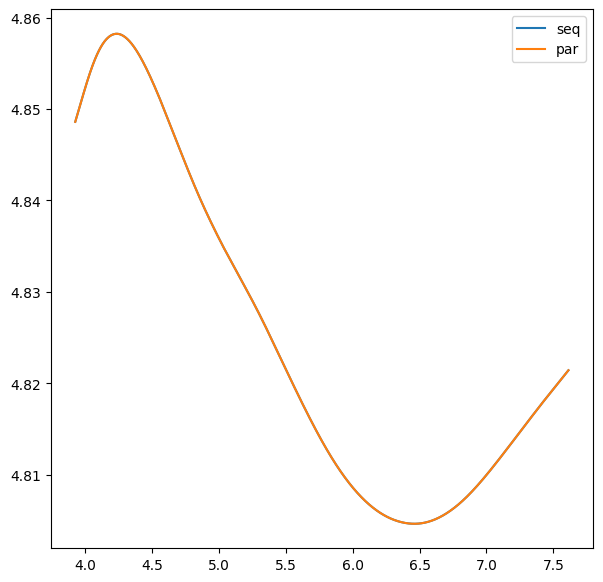

In [8]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [9]:
blocks=steps_all//10
steps=steps_all//blocks
print(blocks,steps,steps_all)

100000 10 1000000


1.0426289601908863e-06


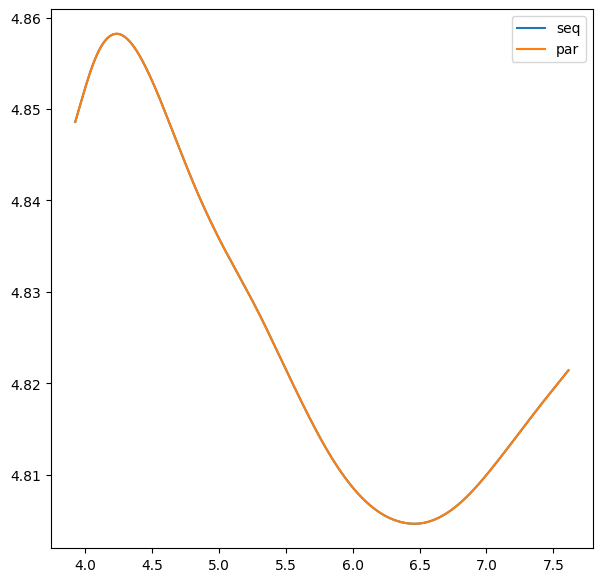

In [10]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [11]:
blocks=steps_all//100
steps=steps_all//blocks
print(blocks,steps,steps_all)

10000 100 1000000


1.0423414416687796e-06


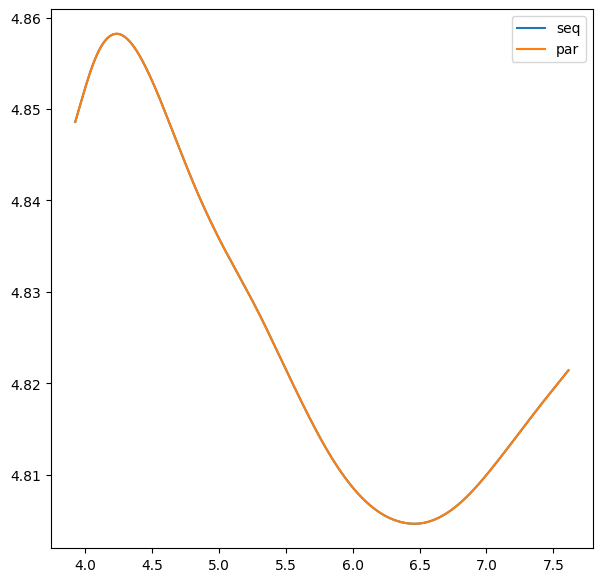

In [12]:
relative_error = accuracy_test_linear_wv(steps, blocks,steps_all,T)

In [13]:
blocks=steps_all//1000
steps=steps_all//blocks
print(blocks,steps,steps_all)

1000 1000 1000000


1.0394745167682517e-06


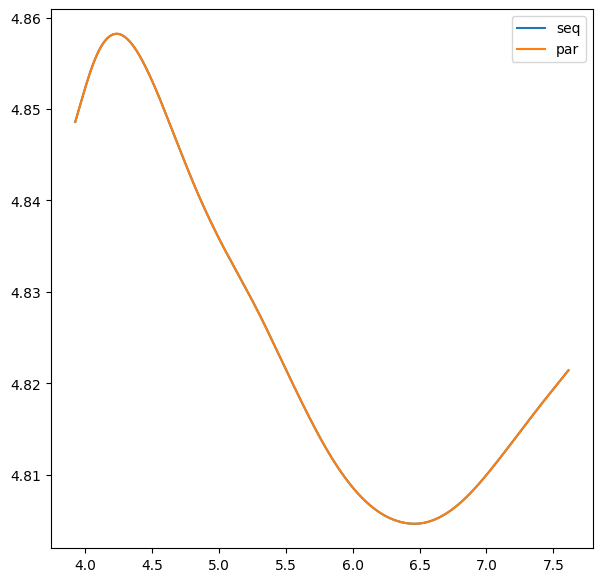

In [14]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [15]:
blocks=steps_all//10000
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 10000 1000000


1.0114701052537646e-06


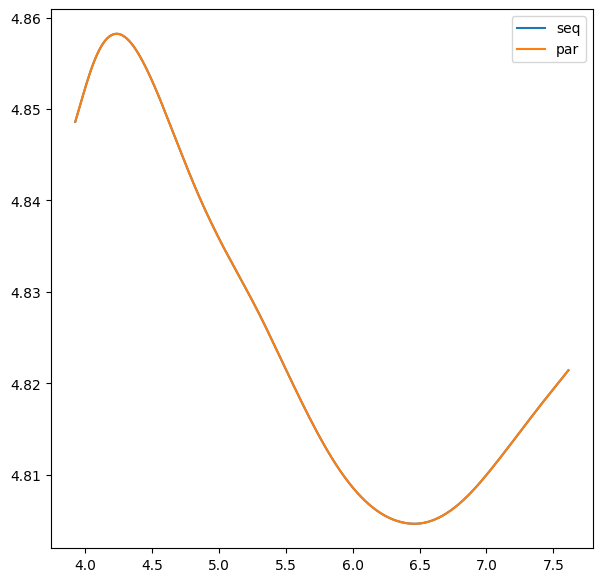

In [16]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [17]:
blocks=steps_all//10000
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 10000 1000000


1.0114701052537646e-06


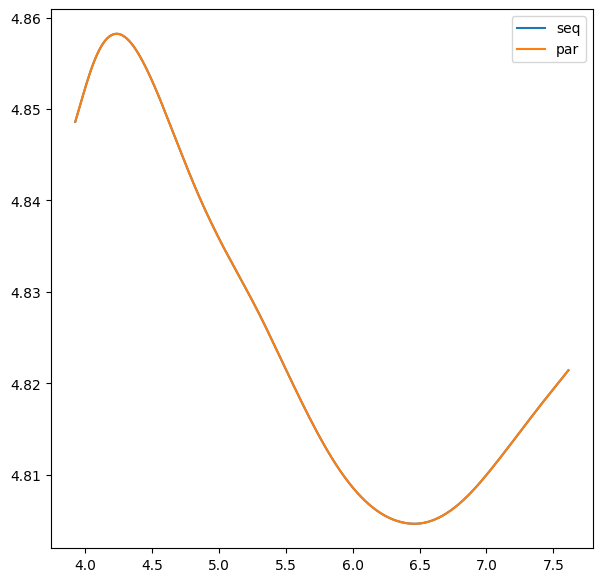

In [18]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

Variant number of total steps

In [19]:
steps_all=5000

In [20]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50 5000


0.00013100441088198642


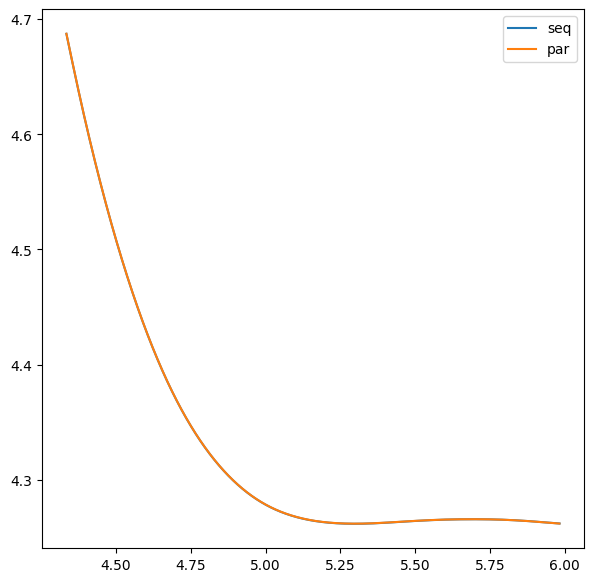

In [21]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [22]:
steps_all=50000

In [23]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 500 50000


1.6888066839726237e-05


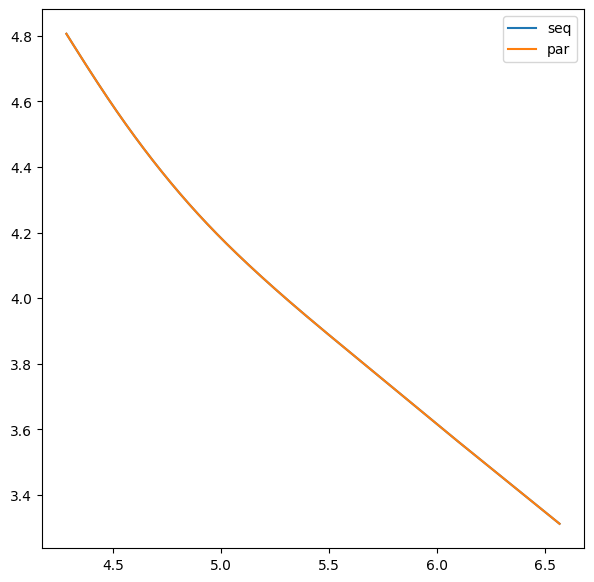

In [24]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [25]:
steps_all=500000

In [26]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 5000 500000


1.6579932242344156e-06


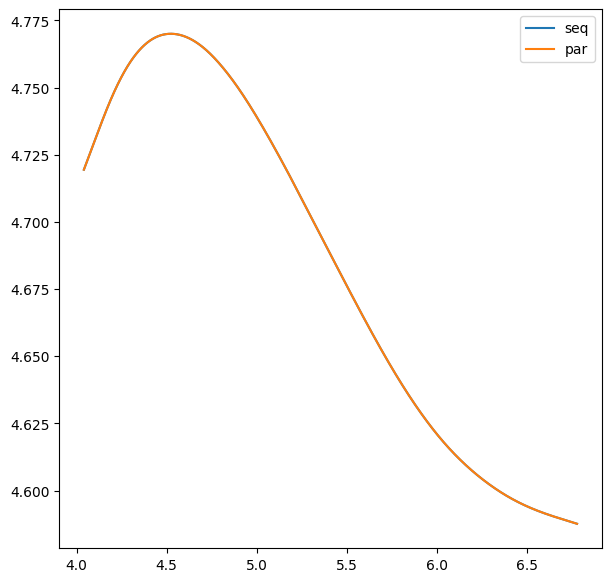

In [27]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [28]:
steps_all=5000000

In [29]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


1.6320132064842085e-07


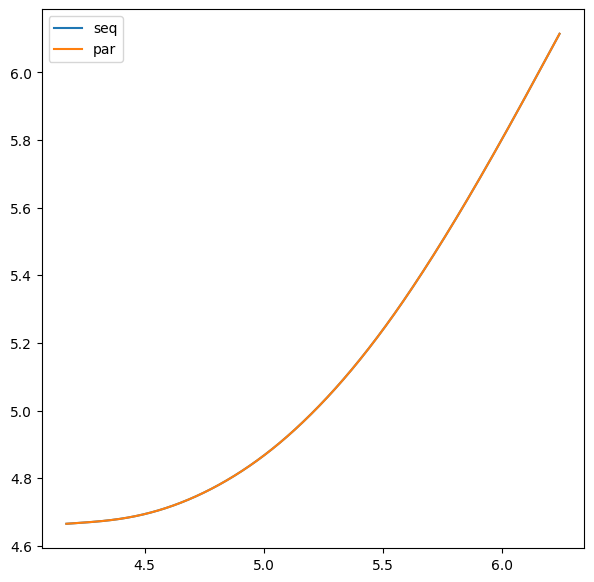

In [30]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

Variant number of total steps with Heun

In [31]:
def accuracy_test_linear_wv_heun(steps, blocks,steps_all,T):
    steps_all=steps*blocks

    dt=T/steps_all

    X, y_discrete, _ = make_wv_data(m0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)

    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)

    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)


 
    T=clqt.T
    dt = clqt.T / steps / blocks
    ST=clqt.ST
    vT=clqt.vT

    S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT,diffeq_solver='heun')
    phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
    x_seq,u_seq =seqForwardPass(clqt, dt, t0, phi0, Kx_seq, d_seq,diffeq_solver='heun',u_zoh=False)


    Kx_par, d_par, S_par, v_par = parBackwardPass(clqt,blocks,steps,t0,dt,diffeq_solver='heun')
    phi0= jnp.linalg.solve(S_par[0] ,v_par[0])

    u_par,x_par = parForwardPass(clqt, phi0, Kx_par, d_par, blocks, steps,dt,t0,diffeq_solver='heun',u_zoh=False)


    f, (ax1) = plt.subplots(1, figsize=(7,7))

    ax1.plot(x_seq[:,0], x_seq[:,1])
    ax1.plot( x_par[:,0],x_par[:,1])
    ax1.legend( ['seq', 'par'])

    relative_error = (
    jnp.linalg.norm(x_seq - x_par)
    / jnp.linalg.norm(x_seq)
   )

    print(relative_error)

    return relative_error



In [32]:
steps_all=5000

In [33]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50 5000


7.629762876757362e-08


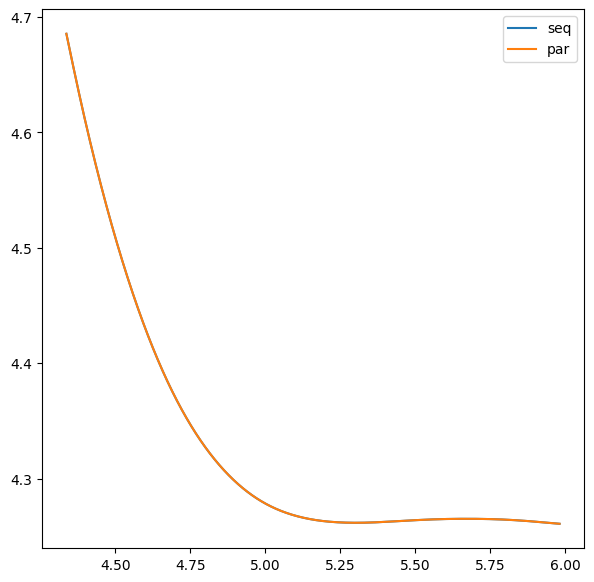

In [34]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [35]:
steps_all=50000

In [36]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 500 50000


1.099848031030373e-09


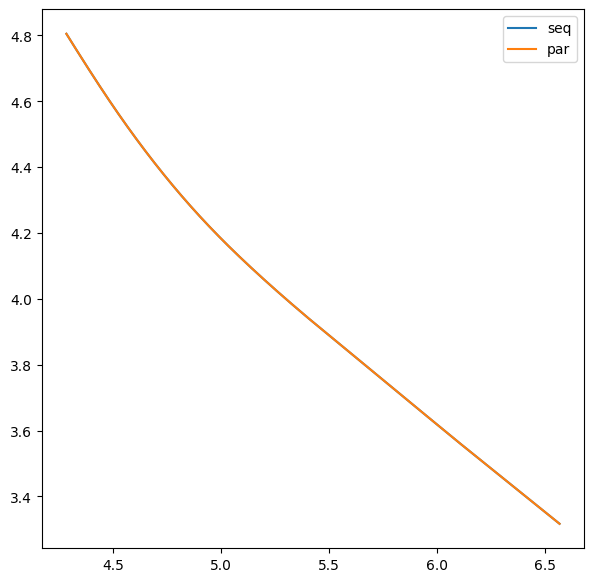

In [37]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [38]:
steps_all=500000

In [39]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 5000 500000


1.1218513489583777e-11


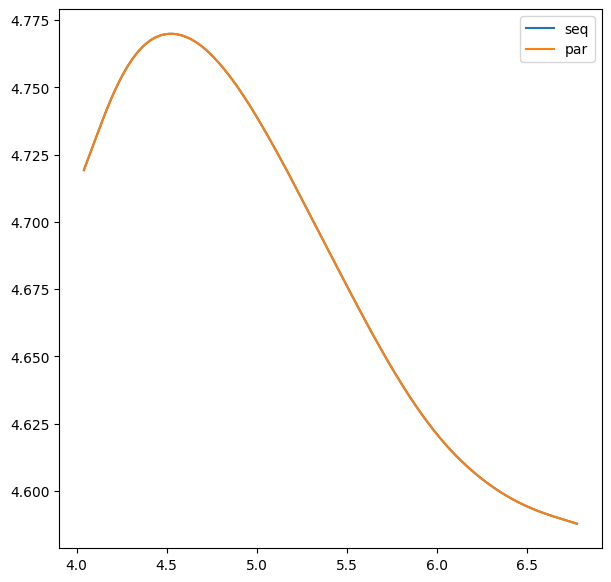

In [40]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [41]:
steps_all=5000000

In [42]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


5.869276336169602e-13


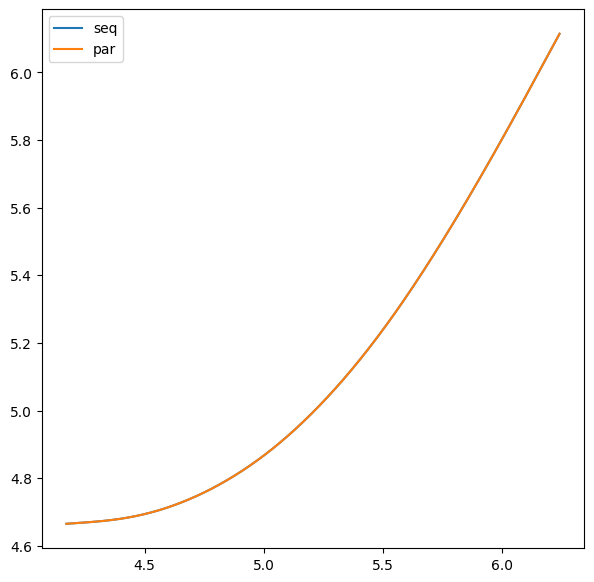

In [43]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)